# Credit Default Case — Update 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


## 1. Correlations between variables

We look at pairwise linear relationships among the numeric loan variables,
then zoom in on two pairs of interest: interest rate vs. FICO score, and
revolving balance vs. revolving utilization.

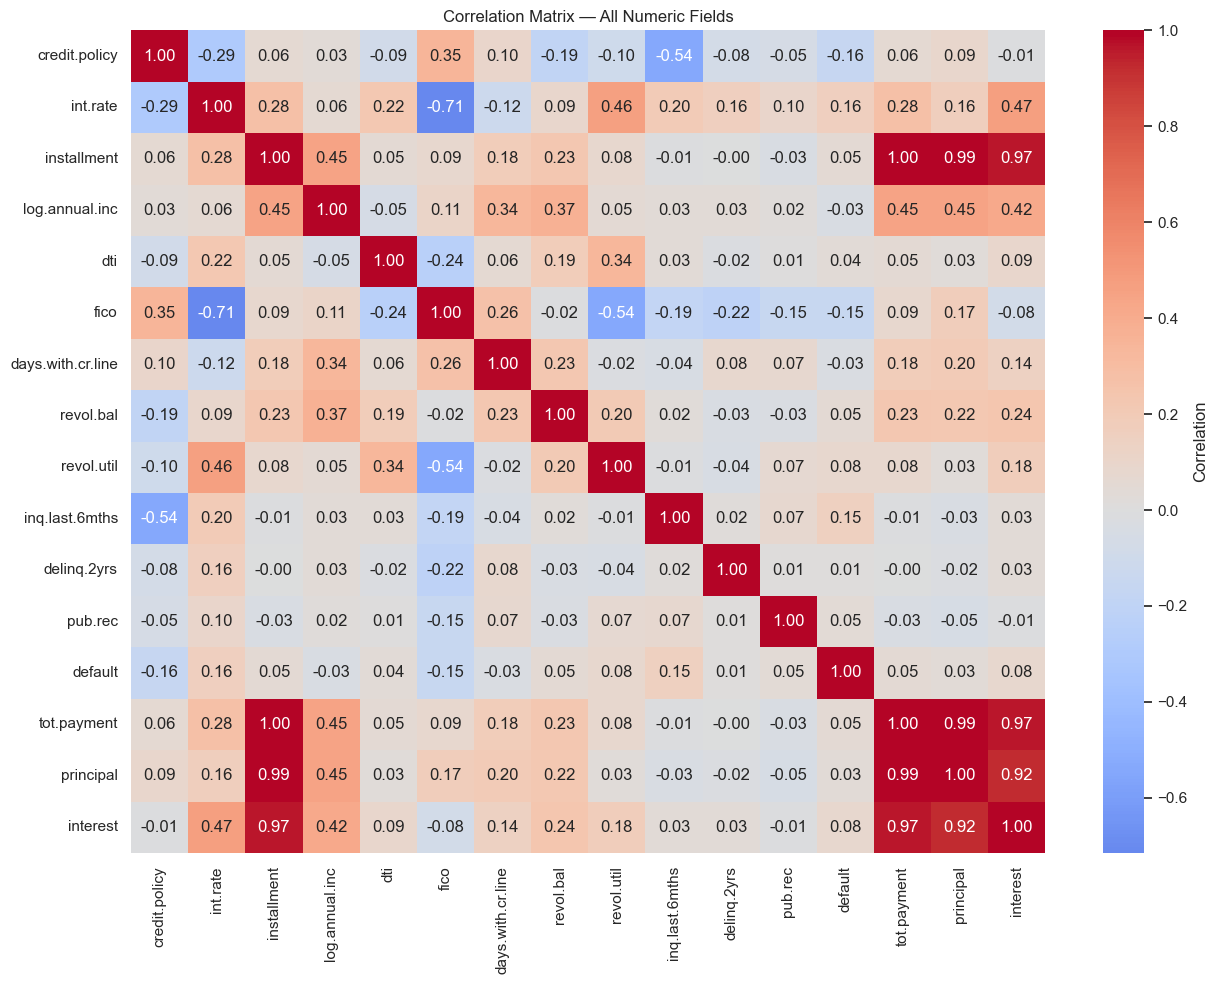

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields')
plt.tight_layout()
plt.show()

In [3]:
top_n = 15
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'var_1', 'level_1': 'var_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_correlation', ascending=False).drop(columns='abs_correlation')

display(corr_pairs.head(top_n).reset_index(drop=True))

,var_1,var_2,correlation
0,installment,tot.payment,1.000000
1,tot.payment,principal,0.990172
2,installment,principal,0.990172
3,installment,interest,0.966023
4,tot.payment,interest,0.966023
5,principal,interest,0.920382
6,int.rate,fico,-0.714821
7,fico,revol.util,-0.541289
8,credit.policy,inq.last.6mths,-0.535511
9,int.rate,interest,0.471355


### 1.1 Interest rate vs. FICO score

Correlation (int.rate, fico): -0.715


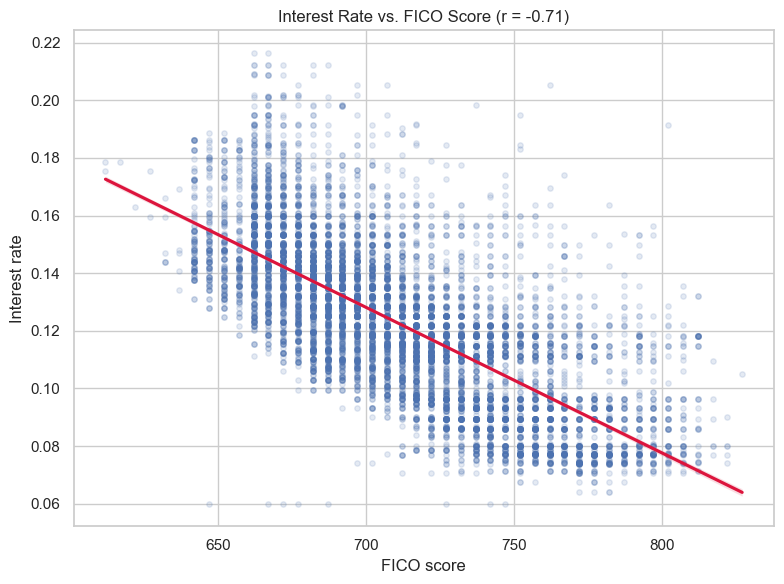

In [4]:
r_rate_fico = df['int.rate'].corr(df['fico'])
print(f"Correlation (int.rate, fico): {r_rate_fico:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='fico', y='int.rate', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.title(f'Interest Rate vs. FICO Score (r = {r_rate_fico:.2f})')
plt.xlabel('FICO score')
plt.ylabel('Interest rate')
plt.tight_layout()
plt.show()

### 1.2 Revolving balance vs. revolving utilization

Correlation (revol.bal, revol.util), full data: 0.204


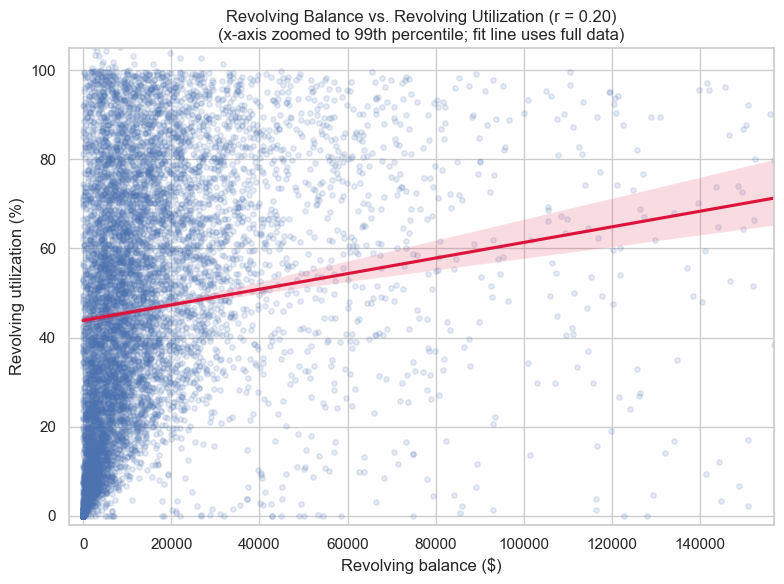

In [5]:
r_bal_util = df['revol.bal'].corr(df['revol.util'])
print(f"Correlation (revol.bal, revol.util), full data: {r_bal_util:.3f}")

x_cap = df['revol.bal'].quantile(0.99)
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='revol.bal', y='revol.util', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.xlim(-x_cap * 0.02, x_cap)
plt.ylim(-2, 105)
plt.title(f'Revolving Balance vs. Revolving Utilization (r = {r_bal_util:.2f})\n'
          f'(x-axis zoomed to 99th percentile; fit line uses full data)')
plt.xlabel('Revolving balance ($)')
plt.ylabel('Revolving utilization (%)')
plt.tight_layout()
plt.show()